# 作业 1：实现 Word2Vec 并在 PTB 数据集上训练

## 作业目标
在本次作业中，你将实现 **Skip-gram + Negative Sampling** 的 Word2Vec 模型，并在 **Penn Treebank (PTB)** 数据集上进行训练。  
通过补全给定的 Notebook 代码，你需要完成以下核心任务：负采样、批次构建、模型和损失定义，以及模型训练。

完成本作业后，你应该能够：
- 掌握 Word2Vec 的核心原理（Skip-gram + Negative Sampling）  
- 了解文本数据的预处理流程，包括构建词典、二次采样、生成训练样本  
- 使用 **PyTorch** 实现并训练一个简单的词向量模型  
- 观察训练得到的词向量效果，通过最近邻词测试验证词语语义相似性  

---

## 提交要求
1. 完整的 `.ipynb` 文件，包含你实现的 PyTorch 代码  
2. Notebook 的运行记录，这将包含每个epoch输出的loss记录
3. 词向量测试结果：给定几个 query token，输出它们的最近邻词，并写简要分析  

---

## Part 0: 导入依赖

In [1]:
import collections
import math
import os
import json
import torch
from torch.utils.data import DataLoader, TensorDataset
import torch.nn as nn
import torch.optim as optim
import random
import sys
import time
import zipfile
import matplotlib.pyplot as plt

## Part 1: 读取 PTB 数据并构建词典

PTB 数据集是语言模型常用的文本语料库。我们会对其进行以下处理：
- 读取数据
- 构建词典，过滤低频词（频率 < 5 的丢弃）
- 将单词映射为整数 ID

In [2]:
with open('data/ptb.train.txt', 'r') as f:
    lines = f.readlines()
    # st是sentence的缩写
    raw_dataset = [st.split() for st in lines]

In [3]:
# 为了计算简单，我们只保留在数据集中至少出现5次的词
counter = collections.Counter([tk for st in raw_dataset for tk in st])
counter = dict(filter(lambda x: x[1] >= 5, counter.items()))

# 然后将词映射到整数索引
idx_to_token = [tk for tk, _ in counter.items()]
token_to_idx = {tk: idx for idx, tk in enumerate(idx_to_token)}
dataset = [[token_to_idx[tk] for tk in st if tk in token_to_idx]
           for st in raw_dataset]
num_tokens = sum([len(st) for st in dataset])

## Part 2: 二次采样 (Subsampling)

高频词（如 "the", "a"）会主导训练，但它们并不携带太多语义信息。
我们对高频词进行二次采样，降低它们出现的概率。

In [4]:
def discard(idx):
    return random.uniform(0, 1) < 1 - math.sqrt(
        1e-4 / counter[idx_to_token[idx]] * num_tokens)

subsampled_dataset = [[tk for tk in st if not discard(tk)] for st in dataset]

## Part 3: 提取中心词和上下文词
我们将与中心词距离不超过背景窗口大小的词作为它的背景词。下面定义函数提取出所有中心词和它们的背景词。它每次在整数1和max_window_size（最大背景窗口）之间随机均匀采样一个整数作为背景窗口大小。

In [5]:
def get_centers_and_contexts(dataset, max_window_size):
    centers, contexts = [], []
    for st in dataset:
        if len(st) < 2:  # 每个句子至少要有2个词才可能组成一对“中心词-背景词”
            continue
        centers += st
        for center_i in range(len(st)):
            window_size = random.randint(1, max_window_size)
            indices = list(range(max(0, center_i - window_size),
                                 min(len(st), center_i + 1 + window_size)))
            indices.remove(center_i)  # 将中心词排除在背景词之外
            contexts.append([st[idx] for idx in indices])
    return centers, contexts

all_centers, all_contexts = get_centers_and_contexts(subsampled_dataset, 5)

## Part 4: 负采样 (Negative Sampling)
我们使用负采样来进行近似训练。对于一对中心词和背景词，我们随机采样 K 个噪声词（实验中设 K=5）。根据word2vec论文的建议，噪声词采样概率 P(w) 设为 w 词频与总词频之比的0.75次方。

In [6]:
def get_negatives(all_contexts, sampling_weights, K):
    all_negatives, neg_candidates, i = [], [], 0
    population = list(range(len(sampling_weights)))
    for contexts in all_contexts:
        negatives = []
        while len(negatives) < len(contexts) * K:
            # TODO:  1.当候选集用完时，重新采样
            #       2.取出一个负例，并更新索引
            #       3.如果负例不在背景词中，则加入 negatives
            if i == len(neg_candidates):
                neg_candidates = random.choices(
                    # 一次性采样 1000 个 neg_candidates 避免多次重复采样浪费时间
                    population, weights=sampling_weights, k=1000
                )
                i = 0
            neg = neg_candidates[i]
            i += 1
            if neg not in contexts:
                negatives.append(neg)
        all_negatives.append(negatives)
    return all_negatives


sampling_weights = [counter[w] ** 0.75 for w in idx_to_token]
all_negatives = get_negatives(all_contexts, sampling_weights, 5)

## Part 5: 构建批量 (Batchify)

为了高效训练，我们需要将训练样本打包成小批量，并对不同长度的上下文和负样本进行 **padding**：

- `centers`：中心词索引  
- `contexts_negatives`：上下文词和负样本拼接后的序列，长度统一为当前 batch 中最大长度  
- `masks`：掩码，标记哪些位置是真实词（1）或填充（0）  
- `labels`：标签，真实上下文词为 1，负样本和 padding 为 0  

请补全以下函数，使其返回四个 **PyTorch Tensor**，供 DataLoader 使用：

In [7]:
def batchify(data):
    """
    将一个批次的数据整理成训练所需的张量格式，包括：
    - centers: 中心词
    - contexts_negatives: 背景词和噪声词拼接并补齐
    - masks: 标记真实词和 padding
    - labels: 背景词为 1，噪声词和 padding 为 0

    参数：
    data : list 类型，每个元素是一个三元组 (center, context, negative)
           - center: 一个中心词索引
           - context: 背景词索引列表
           - negative: 噪声词索引列表
    """

    # TODO:
    # 提示：
    # 1. 先计算每个 batch 中 context + negative 的最大长度 max_len
    # 2. 对每条样本：
    #      - 构造 centers 列表
    #      - 拼接 context + negative，并 pad 到 max_len，形成 contexts_negatives
    #      - 构造 mask：真实词为 1，padding 为 0
    #      - 构造 labels：context 为 1，negative 和 padding 为 0
    # 3. 最后返回四个 Tensor，类型为 torch.float（mask 和 labels 建议转换为 float）

    max_len = max(len(c) + len(n) for _, c, n in data)

    centers = []
    contexts_negatives = []
    masks = []
    labels = []

    for center, context, negative in data:
        centers.append(center)
        contexts_negatives.append(
            context + negative + [0] * (max_len - len(context) - len(negative))
        )
        masks.append(
            [1] * (len(context) + len(negative))
            + [0] * (max_len - len(context) - len(negative))
        )
        labels.append(
            [1] * len(context)
            + [0] * (len(negative) + max_len - len(context) - len(negative))
        )

    return (
        torch.tensor(centers).view(-1, 1),
        torch.tensor(contexts_negatives),
        torch.tensor(masks, dtype=torch.float),
        torch.tensor(labels, dtype=torch.float),
    )

In [8]:
dataset = list(zip(all_centers, all_contexts, all_negatives))
batch_size = 512
data_iter = DataLoader(dataset, batch_size=batch_size, shuffle=True,
                       collate_fn=batchify)

## Part 6: 实现 Skip-gram 模型

在 Skip-gram 模型中，我们使用 **中心词嵌入** 和 **上下文/负样本嵌入** 计算预测分数。  
模型核心操作是通过 **批量矩阵乘法 (batch matrix multiplication)** 计算每个中心词和其上下文/负样本的相似度。

请补全以下函数，实现 Skip-gram 的前向计算：

In [9]:
def skip_gram(center, contexts_and_negatives, embed_v, embed_u):
    """
    参数：
    center: Tensor, (batch_size, 1)，中心词索引
    contexts_and_negatives: Tensor, (batch_size, num_context_negatives)，上下文词 + 负样本索引
    embed_v: nn.Embedding, 中心词嵌入层
    embed_u: nn.Embedding, 上下文/负样本嵌入层

    返回：
    pred: Tensor, (batch_size, 1, num_context_negatives)，预测分数
    """
    
    # TODO: 
    # 提示：
    # 1. 通过 embed_v(center) 获取中心词嵌入 v
    # 2. 通过 embed_u(contexts_and_negatives) 获取上下文/负样本嵌入 u
    # 3. 使用 torch.bmm 进行批量矩阵乘法计算预测分数
    # 4. 返回 pred，形状应为 (batch_size, 1, num_context_negatives)
    
    v = embed_v(center)  # (batch_size, 1, embed_size)
    u = embed_u(contexts_and_negatives)  # (batch_size, num_context_negatives, embed_size)
    pred = torch.bmm(v, u.permute(0, 2, 1))  # (batch_size, 1, num_context_negatives)
    return pred

## Part 7: 实现损失函数 (Binary Cross-Entropy Loss)

在 Skip-gram + 负采样中，我们使用 **Binary Cross-Entropy Loss** 来衡量中心词和上下文/负样本的匹配程度。  

### 公式
$$
\text{BCE}(p, y) = - [y \log(\sigma(p)) + (1-y) \log(1-\sigma(p))]
$$

- \(p\) : 模型预测的 raw logits  
- \(y\) : 标签 (context=1, negative/padding=0)  
- \(\sigma(p)\) : Sigmoid 函数  

为了屏蔽 padding 对损失的影响，需要使用 **mask**：
$$
\text{loss} = \frac{\sum (\text{BCE}(p, y) \cdot \text{mask})}{\sum \text{mask}}
$$

In [10]:
def sigmoid_binary_cross_entropy(pred, label, mask):
    """
    参数：
    pred: Tensor, 预测分数，形状 (batch_size, 1, num_context_negatives)
    label: Tensor, 标签，context=1, negative/padding=0，形状 (batch_size, num_context_negatives)
    mask: Tensor, 掩码，真实词=1, padding=0，形状 (batch_size, num_context_negatives)

    返回：
    loss: Tensor, batch 平均损失 (标量)
    """
    
    # TODO: 自行实现损失函数
    # 提示：
    # 1. 对 pred 应用 torch.sigmoid() 计算概率
    # 2. 按 Binary Cross-Entropy 公式计算每个位置的损失
    # 3. 乘上 mask，忽略 padding
    # 4. 对 batch 求平均返回标量 loss
    
    # 将 pred 展平以匹配 label 的形状
    pred = pred.squeeze(1)  # (batch_size, num_context_negatives)
    
    # 计算 BCE 损失
    p = torch.sigmoid(pred)
    loss = - (label * torch.log(p + 1e-10) + (1 - label) * torch.log(1 - p + 1e-10))
    loss = (loss * mask).sum() / mask.sum()
    
    return loss

## Part 8: 初始化词向量嵌入 (Embedding Layers)

在 Skip-gram 模型中，需要两个嵌入层：
- **中心词嵌入** `embed_v`：负责将中心词索引映射为向量  
- **上下文/负样本嵌入** `embed_u`：负责将上下文词和负样本索引映射为向量  

### 提示
- 词表大小：`vocab_size = len(idx_to_token)`  
- 词向量维度：`embed_size = 100`（可自行调整实验进行尝试）  
- 使用 PyTorch 的 **nn.Embedding** 层来创建嵌入  
- 两个嵌入层初始化方法类似，但是不同的对象
- Embedding 层会在训练过程中被更新，不需要自己手动初始化权重

In [11]:
# TODO: 初始化 embed_v
embed_v = nn.Embedding(len(idx_to_token), 200)

# TODO: 初始化 embed_u
embed_u = nn.Embedding(len(idx_to_token), 200)

## Part 9: 实现训练循环

在本部分，你需要完成训练函数 `train` 中每个批次的核心计算逻辑。  

In [12]:
def train(embed_v, embed_u, lr, num_epochs, data_iter, device):
    import os
    
    embed_v.to(device)
    embed_u.to(device)
    optimizer = optim.Adam(list(embed_v.parameters()) + list(embed_u.parameters()), lr=lr)
    
    # 用于存储每个epoch的loss
    loss_history = []

    for epoch in range(num_epochs):
        l_sum, n = 0.0, 0
        start = time.time()
        for batch in data_iter:
            centers, contexts_negatives, mask, labels = [x.to(device) for x in batch]
            labels = labels.float()
            
            # TODO: 完成训练循环
            # 提示：
            # - 将批次数据输入 skip_gram 模型得到预测
            # - 使用 sigmoid_binary_cross_entropy 计算本次损失 l，注意 mask
            # - 进行反向传播和参数更新（使用 optimizer）
            
            # 前向传播
            pred = skip_gram(centers, contexts_negatives, embed_v, embed_u)
            
            # 计算损失
            l = sigmoid_binary_cross_entropy(pred, labels, mask)
            
            # 反向传播
            optimizer.zero_grad()
            l.backward()
            optimizer.step()

            # 累计本批次 loss 和样本数，用于输出平均 loss
            l_sum += l.item() * mask.size(0)
            n += mask.size(0)
        
        # 计算并保存本epoch的平均loss
        avg_loss = l_sum / n
        loss_history.append(avg_loss)
        print(f'epoch {epoch+1}, loss {avg_loss:.4f}, time {time.time()-start:.2f}s')
    
    # 绘制loss曲线
    plt.figure(figsize=(10, 6))
    plt.plot(range(1, num_epochs + 1), loss_history, 'b-', linewidth=2)
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('Loss', fontsize=12)
    plt.title('Training Loss Curve', fontsize=14)
    plt.grid(True, alpha=0.3)
    plt.xticks(range(1, num_epochs + 1))
    plt.show()
    
    return embed_v, embed_u, loss_history


def save_model(embed_v, embed_u, token_to_idx, idx_to_token, save_dir='checkpoints'):
    """
    保存模型权重和相关配置
    
    参数:
        embed_v: 中心词嵌入层
        embed_u: 上下文词嵌入层
        token_to_idx: 词到索引的映射
        idx_to_token: 索引到词的映射
        save_dir: 保存目录
    """
    os.makedirs(save_dir, exist_ok=True)
    torch.save({
        'embed_v_state_dict': embed_v.state_dict(),
        'embed_u_state_dict': embed_u.state_dict(),
    }, os.path.join(save_dir, 'word2vec_model.pt'))
    
    vocab_data = {
        'token_to_idx': token_to_idx,
        'idx_to_token': idx_to_token
    }
    
    with open(os.path.join(save_dir, 'vocab.json'), 'w', encoding='utf-8') as f:
        json.dump(vocab_data, f, ensure_ascii=False, indent=2)
    


def load_model(save_dir='checkpoints', device='cpu'):
    """
    加载保存的模型
    
    参数:
        save_dir: 模型保存目录
        device: 设备
    
    返回:
        embed_v, embed_u, token_to_idx, idx_to_token
    """

    with open(os.path.join(save_dir, 'vocab.json'), 'r', encoding='utf-8') as f:
        vocab_data = json.load(f)
    
    token_to_idx = vocab_data['token_to_idx']
    idx_to_token = vocab_data['idx_to_token']

    checkpoint = torch.load(os.path.join(save_dir, 'word2vec_model.pt'), map_location=device)
    embed_v = nn.Embedding(len(idx_to_token), checkpoint['embed_v_state_dict']['weight'].shape[1])
    embed_u = nn.Embedding(len(idx_to_token), checkpoint['embed_u_state_dict']['weight'].shape[1])
    
    embed_v.load_state_dict(checkpoint['embed_v_state_dict'])
    embed_u.load_state_dict(checkpoint['embed_u_state_dict'])
    
    embed_v.to(device)
    embed_u.to(device)
    
    return embed_v, embed_u, token_to_idx, idx_to_token

epoch 1, loss 5.2560, time 16.05s
epoch 2, loss 4.5433, time 15.46s
epoch 3, loss 3.8291, time 15.12s
epoch 4, loss 3.1478, time 15.29s
epoch 5, loss 2.5769, time 14.90s
epoch 6, loss 2.1348, time 15.52s
epoch 7, loss 1.7988, time 15.72s
epoch 8, loss 1.5396, time 15.55s
epoch 9, loss 1.3346, time 15.03s
epoch 10, loss 1.1683, time 15.15s
epoch 11, loss 1.0314, time 12.52s
epoch 12, loss 0.9172, time 11.12s
epoch 13, loss 0.8215, time 11.36s
epoch 14, loss 0.7408, time 11.38s
epoch 15, loss 0.6727, time 11.24s
epoch 16, loss 0.6151, time 11.19s
epoch 17, loss 0.5664, time 10.92s
epoch 18, loss 0.5251, time 10.95s
epoch 19, loss 0.4901, time 11.01s
epoch 20, loss 0.4602, time 10.90s
epoch 21, loss 0.4347, time 11.27s
epoch 22, loss 0.4128, time 10.78s
epoch 23, loss 0.3939, time 11.10s
epoch 24, loss 0.3776, time 10.99s
epoch 25, loss 0.3634, time 11.95s
epoch 26, loss 0.3510, time 12.64s
epoch 27, loss 0.3400, time 15.07s
epoch 28, loss 0.3304, time 15.71s
epoch 29, loss 0.3217, time 1

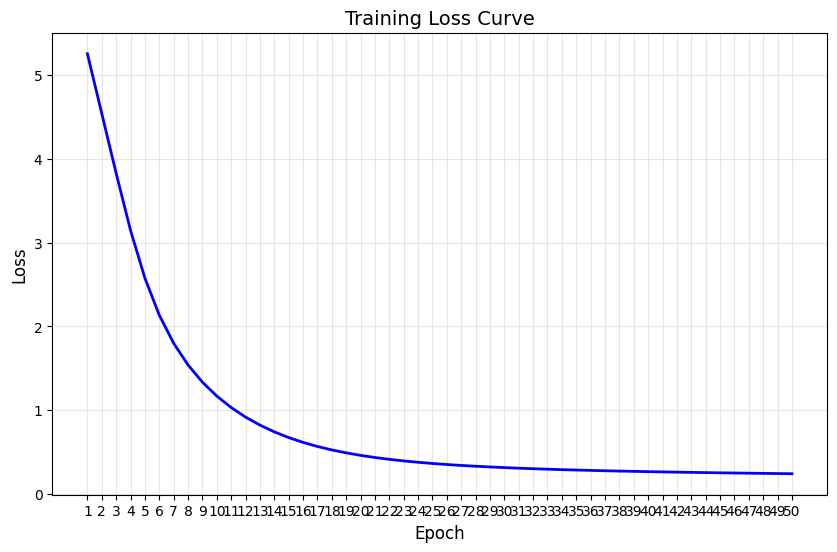

(Embedding(9858, 200),
 Embedding(9858, 200),
 [5.256047878899593,
  4.54332310964871,
  3.8291114239142217,
  3.1477997255934236,
  2.5768534858137473,
  2.134767044045581,
  1.798837068952511,
  1.539627085435353,
  1.3345506539473568,
  1.1683234657447388,
  1.0314029840466703,
  0.9172239826702777,
  0.8214898045357059,
  0.7407944055142596,
  0.6727177498301077,
  0.6151238822142402,
  0.5664284043015043,
  0.5251203580821574,
  0.49008607165700835,
  0.46023985919289756,
  0.4347012887928258,
  0.4128029961491925,
  0.3939100801066056,
  0.3776066409848962,
  0.36341489199353644,
  0.3509682748180922,
  0.34003006878993747,
  0.3303669339507058,
  0.32174222303776046,
  0.3140166105312552,
  0.30707281597888325,
  0.30078902610886127,
  0.29507156709172616,
  0.2898420186203457,
  0.2850475528877775,
  0.2806209576885146,
  0.27654158038544674,
  0.2727096951932545,
  0.2691560964373869,
  0.2658246552632058,
  0.262743632341289,
  0.25979251783386753,
  0.257017244889786,
  0.25

In [13]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

num_epochs = 50
lr = 0.001

train(embed_v, embed_u, lr=lr, num_epochs=num_epochs, data_iter=data_iter, device=device)

In [14]:
save_model(embed_v, embed_u, token_to_idx, idx_to_token, save_dir="output/initial")

## Part 10: 最近邻词测试（找同类词）

为了观察训练得到的词向量效果，我们已经提供了 `get_similar_tokens` 函数。  

请学生执行以下操作：

1. 使用提供的函数，输入不同的查询词（例如 `'computer'`、`'chip'` 等）  
2. 输出对应的前 k 个相似词  
3. 记录每次查询的结果，并思考以下问题：
   - 输出的词是否语义相关？  
   - 有哪些意外的相似词？为什么会出现？  
   - 模型训练过程中可能导致这些结果的原因

In [15]:
def get_similar_tokens(query_token, k, embed):
    W = embed.weight.data  # (vocab_size, embed_size)
    x = W[token_to_idx[query_token]]  # (embed_size,)

    cos = torch.matmul(W, x) / (
        torch.norm(W, dim=1) * torch.norm(x) + 1e-9
    )

    topk = torch.topk(cos, k=k+1).indices.tolist()

    print(f"Top {k} words similar to '{query_token}':")
    for i in topk[1:]:
        print(f"cosine sim={cos[i].item():.3f}: {idx_to_token[i]}")

In [ ]:
get_similar_tokens('classroom', 10, embed_v) 

Top 10 words similar to 'classroom':
cosine sim=0.285: hundreds
cosine sim=0.273: lion
cosine sim=0.273: school
cosine sim=0.271: lawyers
cosine sim=0.268: favorite
cosine sim=0.267: octel
cosine sim=0.262: vienna
cosine sim=0.261: episodes
cosine sim=0.260: calif.-based
cosine sim=0.258: guy


In [17]:
get_similar_tokens('he', 10, embed_v) 

Top 10 words similar to 'he':
cosine sim=0.553: his
cosine sim=0.493: it
cosine sim=0.488: mr.
cosine sim=0.483: but
cosine sim=0.483: that
cosine sim=0.464: 's
cosine sim=0.455: this
cosine sim=0.447: the
cosine sim=0.443: a
cosine sim=0.435: <unk>


In [18]:
# 多义词
get_similar_tokens("bank", 10, embed_v)

Top 10 words similar to 'bank':
cosine sim=0.413: investment
cosine sim=0.390: federal
cosine sim=0.347: international
cosine sim=0.340: had
cosine sim=0.330: million
cosine sim=0.328: real-estate
cosine sim=0.326: to
cosine sim=0.322: minister
cosine sim=0.321: yield
cosine sim=0.320: of


In [19]:
get_similar_tokens("responsibility", 10, embed_v)

Top 10 words similar to 'responsibility':
cosine sim=0.339: arguing
cosine sim=0.297: decision
cosine sim=0.286: served
cosine sim=0.281: auditors
cosine sim=0.278: nights
cosine sim=0.277: black
cosine sim=0.275: without
cosine sim=0.274: drexel
cosine sim=0.271: many
cosine sim=0.264: reform


In [20]:
get_similar_tokens("eagerness", 10, embed_v)

Top 10 words similar to 'eagerness':
cosine sim=0.279: genuine
cosine sim=0.275: presumably
cosine sim=0.271: trading
cosine sim=0.268: arctic
cosine sim=0.264: morning
cosine sim=0.260: explosion
cosine sim=0.257: pro-choice
cosine sim=0.252: impending
cosine sim=0.248: sole
cosine sim=0.247: pasadena


## 作业要求

请你补全以上所有 TODO 部分，完成以下任务：

1. 训练模型，并保留记录 loss 的输出记录（提交时保留notebook里的记录）。  
2. 输出 5 个 query token 的最近邻词结果，并进行简要分析，思考词向量是否捕捉到语义相似性。  
3. 如果你对超参数（包括词向量维度 `embed_size`，学习率 `lr` 和训练轮数 `num_epochs`）进行了探索，请思考并分析这些超参数对训练过程、loss 收敛情况以及最终词向量质量的影响。  

第2、3条要求可以在下面新建一个markdown单元格进行分析。

## 语义相似性的捕捉

选定超参数：`num_epochs=50`, `learning_rate=0.001`, `embed_size=200`

选定的测试词：
- 简单单词：classroom
- 频繁出现的单词：he
- 多义词：bank
- 复杂的单词：eagerness, responsibility

从实验结果来看，Word2Vec模型在不同类型的词语上表现出显著差异。对于高频功能词"he"，模型捕捉到了非常好的语法关系，与其最相似的词包括"his"（0.553）、"it"（0.493）、"mr."、"but"、"that"等，这些都是在相似句法环境中出现的代词和功能词，余弦相似度普遍较高（0.435-0.553）。对于多义词"bank"，模型主要学习到了其金融含义，相似词包括"investment"（0.413）、"federal"（0.390）、"million"、"real-estate"、"yield"等，这符合PTB数据集主要来自华尔街日报的新闻语料特点。然而，对于简单名词"classroom"，虽然"school"（0.273）在结果中，但其他相似词如"lion"、"lawyers"、"vienna"等缺乏语义关联，且余弦相似度整体偏低（0.258-0.285）。

对于复杂抽象词，"responsibility"的相似词中有"arguing"（0.339）、"decision"、"auditors"、"reform"等词具有一定的语义关联性，而"eagerness"的相似词如"genuine"（0.279）、"presumably"、"arctic"、"morning"、"explosion"等则几乎没有明显的语义联系，余弦相似度也很低（0.247-0.279）。这种差异主要源于词频和语境多样性：高频词有足够的训练样本使模型学习到可靠的向量表示，而低频词尤其是抽象词由于样本稀少，模型难以捕捉到稳定的语义特征。此外，PTB数据集的领域偏向性（金融新闻）也影响了词向量的学习，使得某些词语的语义关系更加倾向于财经语境。后续优化可以考虑使用更加广泛的语料训练文本进行训练。

## 超参数训练分析与最终词向量训练质量的影响

### Experiment Settings

我们主要探究如下三个超参数：`num_epochs`, `learning_rate`, `embed_size` 对训练 Loss 收敛情况、最终词向量的质量的影响。

### `learning_rate`

- `learning_rate`: 0.001, 0.005, 0.0001
- choose embed_size: 200, epoch: 50

### `num_epochs`

### `embed_size`

- `embed_size`: 20, 100, 200, 500, 1000
- `learning_rate`: 0.001
- `epoch`: 50

详细的实验结果和分析见附件 PDF。